# **ESCUELA POLITECNICA NACIONAL**
- **Nombre:** Luis Lema
- **Curso:** GR1CC
- **Fecha:** 07/01/2025

## **Respositorio:** https://github.com/LuisALema/Metodos_Numericos_2025B/blob/main/Deberes/Tarea09/Tarea_09.ipynb

## CONJUNTO DE EJERCICIOS. -

### 1. Para cada uno de los siguientes sistemas lineales, obtenga, de ser posible, una solución con métodos gráficos. Explique los resultados desde un punto de vista geométrico.

a. $\begin{cases}
x_1 + 2x_2 = 0, \\
x_1 - x_2 = 0.
\end{cases}$

b. $\begin{cases}
x_1 + 2x_2 = 3, \\
-2x_1 - 4x_2 = 6.
\end{cases}$

c. $\begin{cases}
2x_1 + x_2 = -1, \\
x_1 + x_2 = 2, \\
x_1 - 3x_2 = 5.
\end{cases}$

d. $\begin{cases}
2x_1 + x_2 + x_3 = 1, \\
2x_1 + 4x_2 - x_3 = -1.
\end{cases}$


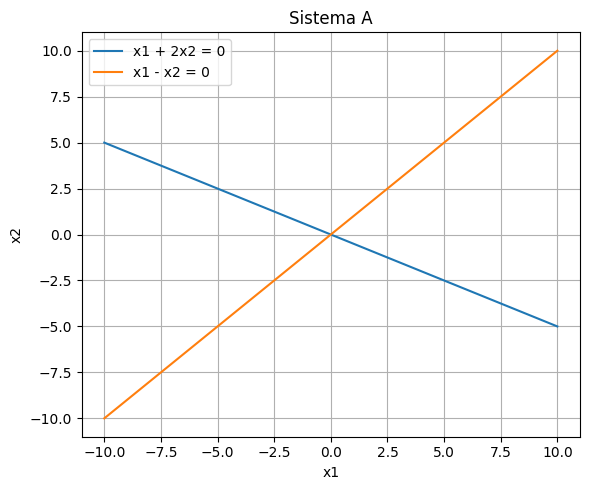

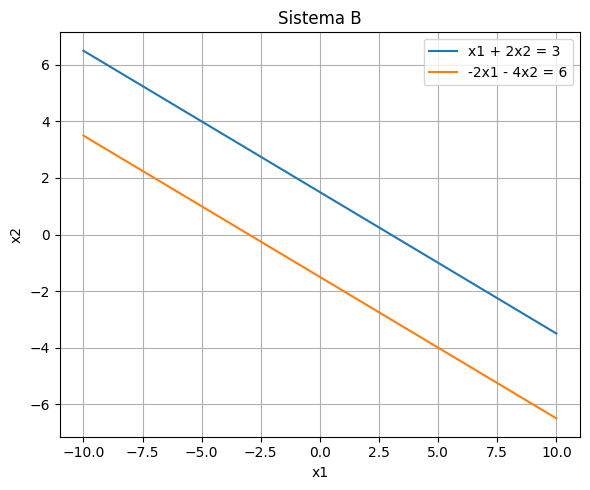

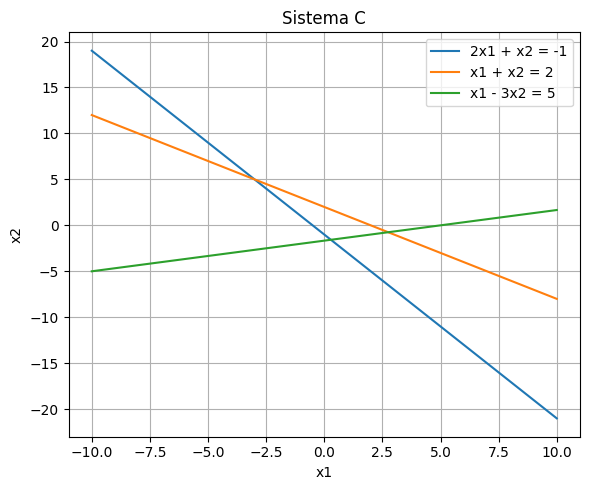

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

# Sistema A
y1 = -x / 2
y2 = x

plt.figure(figsize=(6, 5))
plt.plot(x, y1, label='x1 + 2x2 = 0')
plt.plot(x, y2, label='x1 - x2 = 0')
plt.title('Sistema A')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Sistema B
y3 = (3 - x) / 2
y4 = -(6 + 2*x) / 4

plt.figure(figsize=(6, 5))
plt.plot(x, y3, label='x1 + 2x2 = 3')
plt.plot(x, y4, label='-2x1 - 4x2 = 6')
plt.title('Sistema B')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Sistema C
y5 = -2*x - 1
y6 = 2 - x
y7 = (5 - x) / -3

plt.figure(figsize=(6, 5))
plt.plot(x, y5, label='2x1 + x2 = -1')
plt.plot(x, y6, label='x1 + x2 = 2')
plt.plot(x, y7, label='x1 - 3x2 = 5')
plt.title('Sistema C')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


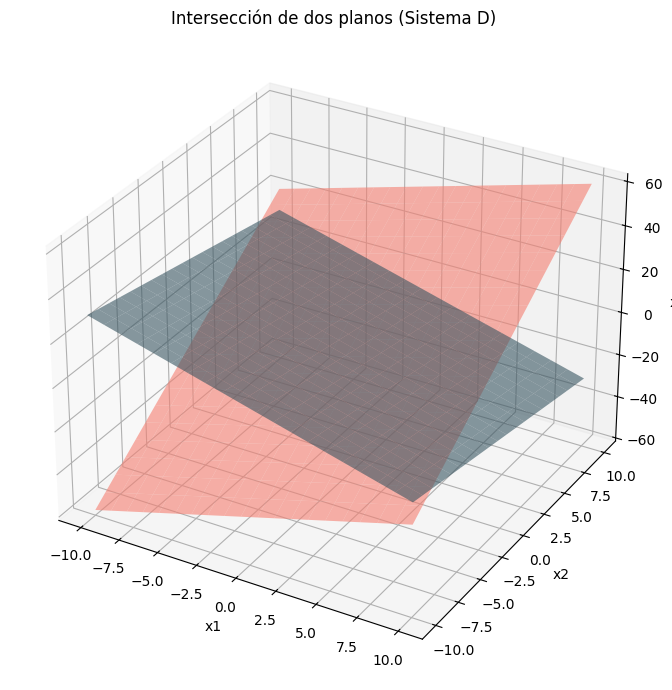

In [2]:
from mpl_toolkits.mplot3d import Axes3D

# Mallas para x1 y x2
x1 = np.linspace(-10, 10, 20)
x2 = np.linspace(-10, 10, 20)
X1, X2 = np.meshgrid(x1, x2)

# Plano 1
Z1 = 1 - 2*X1 - X2

# Plano 2
Z2 = 2*X1 + 4*X2 + 1

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X1, X2, Z1, alpha=0.6, color='skyblue')
ax.plot_surface(X1, X2, Z2, alpha=0.6, color='salmon')

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_title('Intersección de dos planos (Sistema D)')

plt.tight_layout()
plt.show()


### 2. Utilice la eliminación gaussiana con sustitución hacia atrás y aritmética de redondeo de dos dígitos para resolver los siguientes sistemas lineales. No reordene las ecuaciones. (La solución exacta para cada sistema es $x_1=-1$, $x_2=2$, $x_3=3$.)

a. $\begin{cases}
-x_1 + 4x_2 + x_3 = 8, \\
\frac{5}{3}x_1 + \frac{2}{3}x_2 + \frac{2}{3}x_3 = 1, \\
2x_1 + x_2 + 4x_3 = 11.
\end{cases}$

b. $\begin{cases}
4x_1 + 2x_2 - x_3 = -5, \\
\frac{1}{9}x_1 + \frac{1}{9}x_2 - \frac{1}{3}x_3 = -1, \\
x_1 + 4x_2 + 2x_3 = 9.
\end{cases}$


In [ ]:
def eliminacion_gaussiana(M, v):
    n = len(v)
    M = np.hstack((M, v.reshape(-1, 1)))  # matriz aumentada

    for i in range(n):
        for j in range(i + 1, n):
            m = M[j, i] / M[i, i]
            M[j, i:] = M[j, i:] - m * M[i, i:]

    sol = np.zeros(n)
    for i in range(n - 1, -1, -1):
        sol[i] = (M[i, -1] - np.dot(M[i, i+1:n], sol[i+1:])) / M[i, i]

    return np.round(sol, 2)


# Sistema A
A1 = np.array([
    [-1, 4, 1],
    [5/3, 2/3, 2/3],
    [2, 1, 4]
])
b1 = np.array([8, 1, 11])

res_a = eliminacion_gaussiana(A1, b1)
print("Solución del sistema a:", res_a)


# Sistema B
A2 = np.array([
    [4, 2, -1],
    [1/9, 1/9, -1/3],
    [1, 4, 2]
])
b2 = np.array([-5, -1, 9])

res_b = eliminacion_gaussiana(A2, b2)
print("Solución del sistema b:", res_b)


Solución del sistema a: [-1.  1.  3.]
Solución del sistema b: [-1.  1.  3.]


### 3. Utilice el algoritmo de eliminación gaussiana para resolver, de ser posible, los siguientes sistemas lineales, y determine si se necesitan intercambios de fila:

a. $\begin{cases}
x_1 - x_2 + 3x_3 = 2, \\
3x_1 - 3x_2 + x_3 = -1, \\
x_1 + x_2 = 3.
\end{cases}$

b. $\begin{cases}
2x_1 - 1.5x_2 + 3x_3 = 1, \\
-x_1 + 2x_3 = 3, \\
4x_1 - 4.5x_2 + 5x_3 = 1.
\end{cases}$

c. $\begin{cases}
2x_1 = 3, \\
x_1 + 1.5x_2 = 4.5, \\
-3x_2 + 0.5x_3 = -6.6, \\
2x_1 - 2x_2 + x_3 + x_4 = 0.8.
\end{cases}$

d. $\begin{cases}
x_1 + x_2 + x_4 = 2, \\
2x_1 + x_2 - x_3 + x_4 = 1, \\
4x_1 - x_2 - 2x_3 + 2x_4 = 0, \\
3x_1 - x_2 - x_3 + 2x_4 = -3.
\end{cases}$


In [3]:
def gaussian_elimination_with_pivoting(A, b):

    n = len(b)
    A = A.astype(float)  # Asegurarse de que la matriz sea de tipo float
    b = b.astype(float)
    A = np.hstack((A, b.reshape(-1, 1)))  # Matriz aumentada
    swaps = []

    # Eliminación hacia adelante con pivoteo parcial
    for i in range(n):
        # Pivoteo parcial
        max_row = np.argmax(np.abs(A[i:, i])) + i
        if i != max_row:
            A[[i, max_row]] = A[[max_row, i]]
            swaps.append(f"Intercambio de fila {i} con fila {max_row}")

        for j in range(i + 1, n):
            factor = A[j, i] / A[i, i]
            A[j, i:] -= factor * A[i, i:]

    # Sustitución hacia atrás
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (A[i, -1] - np.dot(A[i, i + 1:n], x[i + 1:])) / A[i, i]

    return x, swaps

def main():
    # Sistema a
    A_a = np.array([
        [1, -1, 3],
        [3, -3, 1],
        [1, 1, 0]
    ])
    b_a = np.array([2, -1, 3])

    solution_a, swaps_a = gaussian_elimination_with_pivoting(A_a, b_a)
    print("Sistema a:")
    print("Solución:", solution_a)
    print("Intercambios:", swaps_a)

    # Sistema b
    A_b = np.array([
        [2, -1.5, 3],
        [-1, 0, 2],
        [4, -4.5, 5]
    ])
    b_b = np.array([1, 3, 1])

    solution_b, swaps_b = gaussian_elimination_with_pivoting(A_b, b_b)
    print("\nSistema b:")
    print("Solución:", solution_b)
    print("Intercambios:", swaps_b)

    # Sistema c
    A_c = np.array([
        [2, 0, 0, 0],
        [1, 1.5, 0, 0],
        [-3, 0, 0.5, 0],
        [2, -2, 1, 1]
    ])
    b_c = np.array([3, 4.5, -6.6, 0.8])

    solution_c, swaps_c = gaussian_elimination_with_pivoting(A_c, b_c)
    print("\nSistema c:")
    print("Solución:", solution_c)
    print("Intercambios:", swaps_c)

    # Sistema d
    A_d = np.array([
        [1, 1, 0, 1],
        [2, 1, -1, 1],
        [4, -2, -2, 2],
        [3, -1, -1, 2]
    ])
    b_d = np.array([2, 1, 0, -3])

    solution_d, swaps_d = gaussian_elimination_with_pivoting(A_d, b_d)
    print("\nSistema d:")
    print("Solución:", solution_d)
    print("Intercambios:", swaps_d)

if __name__ == "__main__":
    main()

Sistema a:
Solución: [1.1875 1.8125 0.875 ]
Intercambios: ['Intercambio de fila 0 con fila 1', 'Intercambio de fila 1 con fila 2']

Sistema b:
Solución: [-1. -0.  1.]
Intercambios: ['Intercambio de fila 0 con fila 2']

Sistema c:
Solución: [ 1.5  2.  -4.2  6. ]
Intercambios: ['Intercambio de fila 0 con fila 2', 'Intercambio de fila 1 con fila 3', 'Intercambio de fila 2 con fila 3']

Sistema d:
Solución: [ nan  nan  inf -inf]
Intercambios: ['Intercambio de fila 0 con fila 2']


C:\Users\bzbzb\AppData\Local\Temp\ipykernel_13864\2281164595.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  x[i] = (A[i, -1] - np.dot(A[i, i + 1:n], x[i + 1:])) / A[i, i]
C:\Users\bzbzb\AppData\Local\Temp\ipykernel_13864\2281164595.py:24: RuntimeWarning: invalid value encountered in dot
  x[i] = (A[i, -1] - np.dot(A[i, i + 1:n], x[i + 1:])) / A[i, i]


### 4. Use el algoritmo de eliminación gaussiana y la aritmética computacional de precisión de 32 bits para resolver los siguientes sistemas lineales.

a. $\begin{cases}
\frac{1}{4}x_1 + \frac{1}{5}x_2 + \frac{1}{6}x_3 = 9, \\
\frac{1}{3}x_1 + \frac{1}{4}x_2 + \frac{1}{5}x_3 = 8, \\
\frac{1}{2}x_1 + x_2 + 2x_3 = 8.
\end{cases}$

b. $\begin{cases}
3.333x_1 + 15920x_2 - 10.333x_3 = 15913, \\
2.222x_1 + 16.71x_2 + 9.612x_3 = 28.544, \\
1.5611x_1 + 5.1791x_2 + 1.6852x_3 = 8.4254.
\end{cases}$

c. $\begin{cases}
x_1 + \frac{1}{2}x_2 + \frac{1}{3}x_3 + \frac{1}{4}x_4 = \frac{1}{6}, \\
\frac{1}{2}x_1 + \frac{1}{3}x_2 + \frac{1}{4}x_3 + \frac{1}{5}x_4 = \frac{1}{7}, \\
\frac{1}{3}x_1 + \frac{1}{4}x_2 + \frac{1}{5}x_3 + \frac{1}{6}x_4 = \frac{1}{8}, \\
\frac{1}{4}x_1 + \frac{1}{5}x_2 + \frac{1}{6}x_3 + \frac{1}{7}x_4 = \frac{1}{9}.
\end{cases}$

d. $\begin{cases}
2x_1 + x_2 - x_3 + x_4 - 3x_5 = 7, \\
x_1 + 2x_3 - x_4 + x_5 = 2, \\
-2x_2 - x_3 + x_4 - x_5 = -5, \\
3x_1 + x_2 - 4x_3 + 5x_5 = 6, \\
x_1 - x_2 - x_3 - x_4 + x_5 = -3.
\end{cases}$


In [4]:
def gauss_elim(M, v):
    A = np.array(M, dtype=np.float64)
    b = np.array(v, dtype=np.float64)
    n = b.size

    # Eliminación hacia adelante con pivoteo parcial
    for i in range(n):
        k = i + np.argmax(np.abs(A[i:, i]))
        if k != i:
            A[[i, k]] = A[[k, i]]
            b[[i, k]] = b[[k, i]]

        piv = A[i, i]
        if np.isclose(piv, 0):
            raise ValueError("Sistema singular o sin solución única.")

        for j in range(i + 1, n):
            m = A[j, i] / piv
            A[j, i:] = A[j, i:] - m * A[i, i:]
            b[j] = b[j] - m * b[i]

    # Sustitución hacia atrás
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - np.dot(A[i, i + 1:], x[i + 1:])) / A[i, i]

    return np.round(x, 6)


# Sistemas
sistemas = [
    {"matrix": [[1/4, 1/5, 1/6], [1/3, 1/4, 1/5], [1/2, 1, 2]], "vector": [9, 8, 8]},
    {"matrix": [[3.333, 15920, -10.333], [2.222, 16.71, 9.612], [1.5611, 5.1791, 1.6852]], "vector": [15913, 28.544, 8.4254]},
    {"matrix": [[1, 1/2, 1/3, 1/4], [1/2, 1/3, 1/4, 1/5], [1/3, 1/4, 1/5, 1/6], [1/4, 1/5, 1/6, 1/7]], "vector": [1/5, 1/6, 1/7, 1/9]},
    {"matrix": [[2, 1, -1, -3, -3], [1, 0, 2, -1, -4], [-2, 0, -3, 4, -5], [3, 1, 2, -4, 5], [1, -1, -3, -4, -1]], "vector": [7, 2, -5, 6, -3]}
]

for i, s in enumerate(sistemas):
    print(f"\nSistema {chr(97 + i)}:")
    try:
        sol = gauss_elim(s["matrix"], s["vector"])
        print("Solución:", sol)
    except ValueError as err:
        print(err)



Sistema a:
Solución: [-227.076923  476.923077 -177.692308]

Sistema b:
Solución: [1. 1. 1.]

Sistema c:
Solución: [  1.930159 -23.047619  57.047619 -36.888889]

Sistema d:
Solución: [-5.538462  7.846154  1.307692 -3.487179 -0.358974]


### 5. Dado el sistema lineal:

$$
\begin{cases}
x_1 - x_2 + \alpha x_3 = -2, \\
-x_1 + 2x_2 - \alpha x_3 = 3, \\
\alpha x_1 + x_2 + x_3 = 2.
\end{cases}
$$


- a. Encuentre el valor(es) de 𝛼 para los que el sistema no tiene soluciones.
- b. Encuentre el valor(es) de 𝛼 para los que el sistema tiene un número infinito de soluciones.
- c. Suponga que existe una única solución para una a determinada, encuentre la solución.

In [5]:
def evaluar_sistema(a):
    M = np.array([
        [1, -1, a],
        [-1, 2, -a],
        [a, 1, 1]
    ], dtype=np.float64)
    v = np.array([-2, 3, 2], dtype=np.float64)

    d = np.linalg.det(M)

    if np.isclose(d, 0):
        M_ext = np.column_stack((M, v))
        r_M = np.linalg.matrix_rank(M)
        r_ext = np.linalg.matrix_rank(M_ext)

        if r_M == r_ext:
            return "Infinitas soluciones"
        else:
            return "No tiene solución"
    else:
        sol = np.linalg.solve(M, v)
        return np.round(sol, 4)


valores_alpha = [0, -1, -2, 1, 2, 3]

for a in valores_alpha:
    res = evaluar_sistema(a)
    print(f"Para α = {a}, el resultado es: {res}")


Para α = 0, el resultado es: [-1.  1.  1.]
Para α = -1, el resultado es: Infinitas soluciones
Para α = -2, el resultado es: [-0.3333  1.      0.3333]
Para α = 1, el resultado es: No tiene solución
Para α = 2, el resultado es: [ 1.  1. -1.]
Para α = 3, el resultado es: [ 0.5  1.  -0.5]


In [6]:
def evaluar_sistema(a):
    M = np.array([
        [1, -1, a],
        [-1, 2, -a],
        [a, 1, 1]
    ], dtype=float)

    v = np.array([-2, 3, 2], dtype=float)

    det_M = np.linalg.det(M)

    if np.isclose(det_M, 0):
        rM = np.linalg.matrix_rank(M)
        M_ext = np.column_stack((M, v))
        r_ext = np.linalg.matrix_rank(M_ext)

        if rM == r_ext:
            return f"Para a = {a:.2f}: Infinitas soluciones"
        else:
            return f"Para a = {a:.2f}: No tiene solución"
    else:
        sol = np.linalg.solve(M, v)
        return f"Para a = {a:.2f}: Solución única → x = {np.round(sol, 3)}"


lista_a = [-2, -1, 0, 0.5, 1, 2]

for a in lista_a:
    print(evaluar_sistema(a))


Para a = -2.00: Solución única → x = [-0.333  1.     0.333]
Para a = -1.00: Infinitas soluciones
Para a = 0.00: Solución única → x = [-1.  1.  1.]
Para a = 0.50: Solución única → x = [-2.  1.  2.]
Para a = 1.00: No tiene solución
Para a = 2.00: Solución única → x = [ 1.  1. -1.]


## EJERCICIOS APLICADOS

### 6. Suponga que en un sistema biológico existen n especies de animales y m fuentes de alimento. Si $x_j$ representa la población de las j-ésimas especies, para cada 𝑗 = 1, ⋯ , 𝑛; $b_i$; representa el suministro diario disponible del i-ésimo alimento y $a_{ij}$ representa la cantidad del i-ésimo alimento.
$$
\begin{cases}
a_{11}x_1 + a_{12}x_2 + \cdots + a_{1n}x_n = b_1, \\
a_{21}x_1 + a_{22}x_2 + \cdots + a_{2n}x_n = b_2, \\
\vdots \\
a_{m1}x_1 + a_{m2}x_2 + \cdots + a_{mn}x_n = b_m.
\end{cases}
$$
### representa un equilibrio donde existe un suministro diario de alimento para cumplir con precisión con el promedio diario de consumo de cada especie.

- a. Si
$$
A = [a_{ij}] =
\begin{bmatrix}
1 & 2 & 0 & 3 \\
1 & 0 & 2 & 2 \\
0 & 0 & 1 & 1
\end{bmatrix}
$$


$x=(x_j)=[1000,500,350,400],$ y $b=(b_i)=[3500,2700,900].$ ¿Existe suficiente alimento para satisfacer el consumo promedio diario?

In [7]:
from scipy.optimize import linprog

def verificar_suficiencia(M, x, limite):
    consumo = np.dot(M, x)
    return np.all(consumo <= limite), consumo

A = np.array([
    [1, 2, 0, 3],
    [1, 0, 2, 2],
    [0, 0, 1, 1]
], dtype=float)

x = np.array([1000, 500, 350, 400], dtype=float)
b = np.array([3500, 2700, 900], dtype=float)

ok, consumo_calc = verificar_suficiencia(A, x, b)
print("¿Hay suficiente alimento para satisfacer el consumo promedio diario?", ok)
print("Consumo calculado:", consumo_calc)
print("Suministro disponible:", b)


¿Hay suficiente alimento para satisfacer el consumo promedio diario? True
Consumo calculado: [3200. 2500.  750.]
Suministro disponible: [3500. 2700.  900.]


- b. ¿Cuál es el número máximo de animales de cada especie que se podría agregar de forma individual al sistema con el suministro de alimento que cumpla con el consumo?

- c. Si la especie 1 se extingue, ¿qué cantidad de incremento individual de las especies restantes se podría soportar?

- d. Si la especie 2 se extingue, ¿qué cantidad de incremento individual de las especies restantes se podría soportar?

In [8]:
def obtener_incrementos(M, x, limite):
    M = np.array(M, dtype=float)
    x = np.array(x, dtype=float)
    limite = np.array(limite, dtype=float)

    inc = []
    uso = M @ x
    resto = limite - uso

    for i in range(len(x)):
        col = M[:, i]
        with np.errstate(divide='ignore', invalid='ignore'):
            d = np.where(np.abs(col) > 1e-8, resto / col, np.inf)

        d_ok = d[np.isfinite(d)]
        if d_ok.size > 0:
            max_inc = np.floor(np.min(d_ok))
        else:
            max_inc = 0

        inc.append(int(max_inc))

    return inc


# Datos base
A = [
    [1, 2, 0, 3],
    [1, 0, 2, 2],
    [0, 0, 1, 1]
]
x = [1000, 500, 350, 400]
b = [3500, 2700, 900]

print("🔹 Incrementos individuales permitidos:")
print(obtener_incrementos(A, x, b))


# Caso c: especie 1 extinta
A_c = [fila[1:] for fila in A]
x_c = x[1:]
b_c = np.array(b) - np.array([fila[0] for fila in A]) * x[0]

print("🔹 Incrementos si especie 1 se extingue:")
print(obtener_incrementos(A_c, x_c, b_c))


# Caso d: especie 2 extinta
A_d = [fila[:1] + fila[2:] for fila in A]
x_d = [x[0]] + x[2:]
b_d = np.array(b) - np.array([fila[1] for fila in A]) * x[1]

print("🔹 Incrementos si especie 2 se extingue:")
print(obtener_incrementos(A_d, x_d, b_d))


🔹 Incrementos individuales permitidos:
[200, 150, 100, 100]
🔹 Incrementos si especie 1 se extingue:
[150, 100, 100]
🔹 Incrementos si especie 2 se extingue:
[200, 100, 100]


## EJERCICIOS TEÓRICOS

### 7. Repita el ejercicio 4 con el método Gauss-Jordan.

In [9]:
def metodo_gj(M, v):
    M = M.astype(np.float32)
    v = v.astype(np.float32)
    n = len(v)

    Ab = np.hstack((M, v.reshape(-1, 1)))

    for i in range(n):
        Ab[i] = Ab[i] / Ab[i, i]

        for j in range(n):
            if j != i:
                Ab[j] = Ab[j] - Ab[j, i] * Ab[i]

    return Ab[:, -1]


# Sistema (a)
A_a = np.array([
    [1/4, 1/5, 1/6],
    [1/3, 1/4, 1/5],
    [1/2, 1, 1]
], dtype=np.float32)
b_a = np.array([9, 8, 8], dtype=np.float32)

# Sistema (b)
A_b = np.array([
    [3.333, 15920, 10.333],
    [2.222, 16.71, 9.612],
    [1.5611, 5.1791, 1.6852]
], dtype=np.float32)
b_b = np.array([15913, 28.544, 8.4254], dtype=np.float32)

# Sistema (c)
A_c = np.array([
    [1, 1/2, 1/3, 1/4],
    [1/2, 1/3, 1/4, 1/5],
    [1/3, 1/4, 1/5, 1/6],
    [1/4, 1/5, 1/6, 1/7]
], dtype=np.float32)
b_c = np.array([1/6, 1/7, 1/8, 1/9], dtype=np.float32)

# Sistema (d)
A_d = np.array([
    [2, 1, -1, 1, -3],
    [1, 2, -3, -4, 0],
    [-2, -2, -3, 4, -5],
    [3, 1, -2, -4, 5],
    [1, -1, -3, -4, 1]
], dtype=np.float32)
b_d = np.array([7, 2, -5, 6, -3], dtype=np.float32)

x_a = metodo_gj(A_a, b_a)
x_b = metodo_gj(A_b, b_b)
x_c = metodo_gj(A_c, b_c)
x_d = metodo_gj(A_d, b_d)

print("Solución del sistema (a):", x_a)
print("Solución del sistema (b):", x_b)
print("Solución del sistema (c):", x_c)
print("Solución del sistema (d):", x_d)


Solución del sistema (a): [  306.00003 -1300.0002   1155.0002 ]
Solución del sistema (b): [1.0023832  0.99870026 1.0017889 ]
Solución del sistema (c): [-0.03174722  0.5952536  -2.380991    2.7778032 ]
Solución del sistema (d): [ 2.3945172   1.7342076  -0.06793801  1.0166866   0.20262219]
